In [ ]:
# One-cell setup for fresh environments
%pip install -q pandas numpy scikit-learn xgboost catboost seaborn matplotlib openpyxl



Training: Logistic Regression (L1)
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.91      0.84      0.88      4136
           2       0.74      0.93      0.82      5194
           3       0.76      0.18      0.29      1369
           4       0.00      0.00      0.00         1

    accuracy                           0.80     10710
   macro avg       0.66      0.55      0.57     10710
weighted avg       0.81      0.80      0.77     10710


Training: Logistic Regression (L2)
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.84      0.88      4136
           2       0.74      0.94      0.83      5194
           3       0.81      0.20      0.32      1369
           4       0.00      0.00      0.00         1

    accuracy                           0.81     10710
   macro avg       0.67      0.56      0.57     10710
weigh

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:05:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.92      0.91      0.91      4136
           2       0.76      0.93      0.84      5194
           3       0.75      0.16      0.26      1369
           4       0.00      0.00      0.00         1

    accuracy                           0.82     10710
   macro avg       0.69      0.60      0.60     10710
weighted avg       0.82      0.82      0.79     10710


Training: MLP
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.93      0.88      0.90      4136
           2       0.77      0.91      0.84      5194
           3       0.64      0.29      0.40      1369
           4       0.00      0.00      0.00         1

    accuracy                           0.82     10710
   macro avg       0.67      0.58      0.61     10710
weighted avg       0.81      0.82      0.81     10710


=== Su

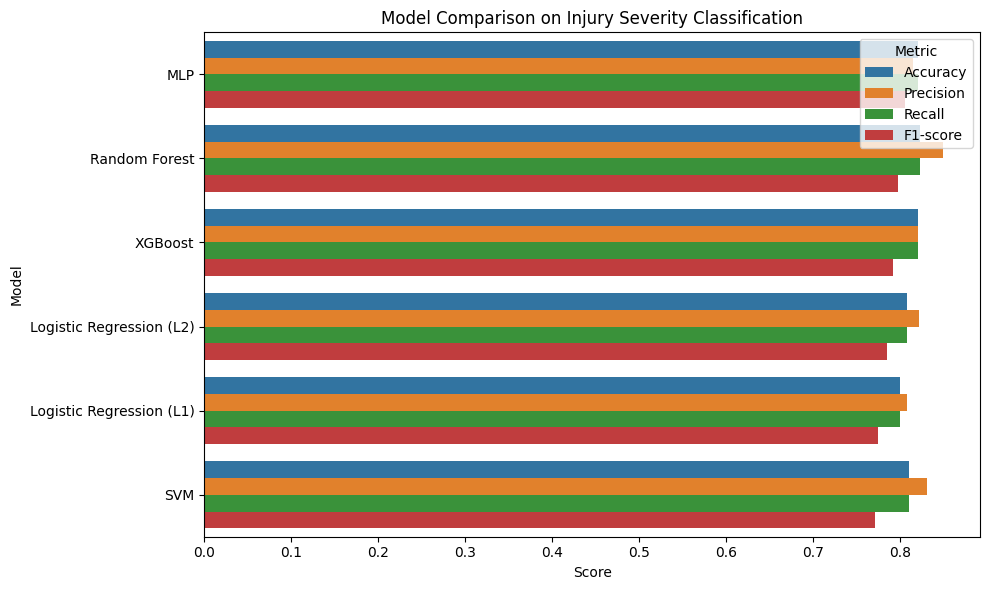

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_excel("Injury Severity.xlsx")
df = df.rename(columns=lambda x: x.strip())

assert "degree_of_inj_x" in df.columns, "Target column 'degree_of_inj_x' no exist"
df = df.dropna(subset=["degree_of_inj_x"])

y = df["degree_of_inj_x"]
X = df.drop(columns=["degree_of_inj_x"])

X.columns = X.columns.astype(str)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].astype(str)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

models = {
    "Logistic Regression (L1)": LogisticRegression(penalty='l1', solver='saga', max_iter=5000),
    "Logistic Regression (L2)": LogisticRegression(penalty='l2', solver='saga', max_iter=5000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss"),
    "MLP": MLPClassifier(max_iter=500)
}

results = []

for name, model in models.items():
    print(f"\nTraining: {name}")
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(classification_report(y_test, y_pred, zero_division=0))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
print("\n=== Summary Table ===")
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"]),
            x="value", y="Model", hue="variable")
plt.title("Model Comparison on Injury Severity Classification")
plt.xlabel("Score")
plt.ylabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()
